# ✈️ Conjunto de datos sobre seguridad aérea mundial (1970-2024)

# Introducción:

Este estudia analiza un conjunto de datos que documenta 55 años de evolución en la seguridad de la aviación comercial. El estudio traza la transformación de la industria desde su década más mortífera en los años 70, hasta la era actual impulsada por sistemas avanzados de gestión de vuelo.

link: https://www.kaggle.com/datasets/sergionefedov/global-aviation-safety-1970-2024-25k-incidents?select=safety_trends.csv

Mineria de datos 002D

Autor: Felipe Rojas Villacura

# Diccionario de datos

Columna    Descripción
incident_id    Identificador único (AV000001–AV025000)

date    Fecha del incidente (AAAA-MM-DD)

airline    Nombre de la aerolínea operadora

aircraft_type    Modelo de la aeronave (p. ej. Boeing 737-800)

aircraft_age_years    Edad de la aeronave en el momento del incidente

departure_airport    Código ICAO del aeropuerto de salida

arrival_airport    Código ICAO del aeropuerto de destino

country    País donde ocurrió el incidente

region    Región geográfica

incident_type    Clasificación del incidente (16 tipos) — ver más abajo

phase_of_flight    despegue / ascenso / crucero / descenso / aproximación / aterrizaje / rodaje / en tierra

weather_conditions    VMC / IMC / IMC-Low / IMC-Fog / Night-VMC / Night-IMC

primary_cause    Categoría de causa raíz

is_fatal    Binario: 1 si hay alguna fatalidad

fatalities    Número de fallecidos (0 si no es fatal)

occupants_onboard    Total de personas a bordo

injuries    Lesiones no fatales

hull_loss    Binario: 1 si la aeronave fue destruida o irreparable

damage_category    Ninguno / Menor / Sustancial / Destruido

investigation_status    Resultado de la investigación NTSB/ICAO


In [1]:
!pip install category_encoders

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import category_encoders as ce

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/MineriaDatos02D/EA1/'

In [5]:
df_incidents = pd.read_csv(path + 'incidents.csv')


In [6]:
pd.options.display.max_columns = None
pd.options.display.max_rows = 9999
pd.options.display.max_colwidth = None

In [7]:
df_incidents.head()

,incident_id,date,year,month,airline,airline_region,airline_country,aircraft_type,aircraft_category,manufacturer,aircraft_age_years,manufacture_year,departure_airport,arrival_airport,country,region,incident_type,phase_of_flight,weather_conditions,primary_cause,is_fatal,fatalities,occupants_onboard,injuries,hull_loss,damage_category,investigation_status,engines,seats_config
0,AV000001,2002-02-27,2002,2,Kenya Airways,Africa,Kenya,HAVILLAND Twin Otter,Turboprop,De Havilland,7,1995,RPVM,RPLL,Philippines,AsiaPacific,Cargo Issue,climb,VMC,loading error,0,0,5,0,0,NaN,Inconclusive,2,20
1,AV000002,1985-01-18,1985,1,TAP Air Portugal,Europe,Portugal,Boeing 777-300ER,Widebody,Boeing,13,2000,YYYY,ZZZZ,Poland,Europe,Engine Failure,cruise,IMC-Fog,manufacturing,0,0,311,51,0,Minor,Probable cause determined,2,396
2,AV000003,2008-08-23,2008,8,American Airlines,NorthAmerica,USA,Boeing 767-400,Widebody,Boeing,21,1990,KLAX,KSFO,USA,NorthAmerica,Controlled Flight into Terrain (CFIT),cruise,IMC-Low,crew error,1,183,245,0,1,Destroyed,Probable cause determined,2,245
3,AV000004,1997-12-28,1997,12,ASKY Airlines,Africa,Togo,Fokker 100,Regional,Fokker,14,1983,KJFK,KMIA,USA,NorthAmerica,Controlled Flight into Terrain (CFIT),descent,VMC,navigation,0,0,45,9,0,Minor,Inconclusive,2,107
4,AV000005,1973-08-05,1973,8,Air France,Europe,France,Boeing 720,Narrowbody,Boeing,10,1963,VNKT,VNPL,Nepal,SouthAsia,Icing,approach,VMC,weather,1,40,127,0,1,Destroyed,Probable cause determined,4,149


In [8]:
print("\nInformación de columnas:")
df_incidents.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   incident_id           25000 non-null  object
 1   date                  25000 non-null  object
 2   year                  25000 non-null  int64 
 3   month                 25000 non-null  int64 
 4   airline               25000 non-null  object
 5   airline_region        25000 non-null  object
 6   airline_country       25000 non-null  object
 7   aircraft_type         25000 non-null  object
 8   aircraft_category     25000 non-null  object
 9   manufacturer          25000 non-null  object
 10  aircraft_age_years    25000 non-null  int64 
 11  manufacture_year      25000 non-null  int64 
 12  departure_airport     25000 non-null  object
 13  arrival_airport       25000 non-null  object
 14  country               25000 non-null  object
 15  region    

In [9]:
print("\nValores nulos:")
print(df_incidents.isna().sum())


Valores nulos:
incident_id                0
date                       0
year                       0
month                      0
airline                    0
airline_region             0
airline_country            0
aircraft_type              0
aircraft_category          0
manufacturer               0
aircraft_age_years         0
manufacture_year           0
departure_airport          0
arrival_airport            0
country                    0
region                     0
incident_type              0
phase_of_flight            0
weather_conditions         0
primary_cause              0
is_fatal                   0
fatalities                 0
occupants_onboard          0
injuries                   0
hull_loss                  0
damage_category         1612
investigation_status       0
engines                    0
seats_config               0
dtype: int64


In [27]:
#Contenido del dataset
print(df_incidents.shape) #hacer graficos

(25000, 80)


Podemos observar que el dataset presenta 1612 nulos en una fila cualitativa muy relevante como es el damage_category de los incidentes. Buscaremos opcion mas optima de hacer una imputacion tratar con esos nulos.

# Fase 2: Entendimiento de los Datos

Dados los datos, haremos un analisis preliminar de variables categoricas

/tmp/ipykernel_3551/3065733307.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_incidents, x='weather_conditions', ax=axes[4], palette='viridis', edgecolor='black')


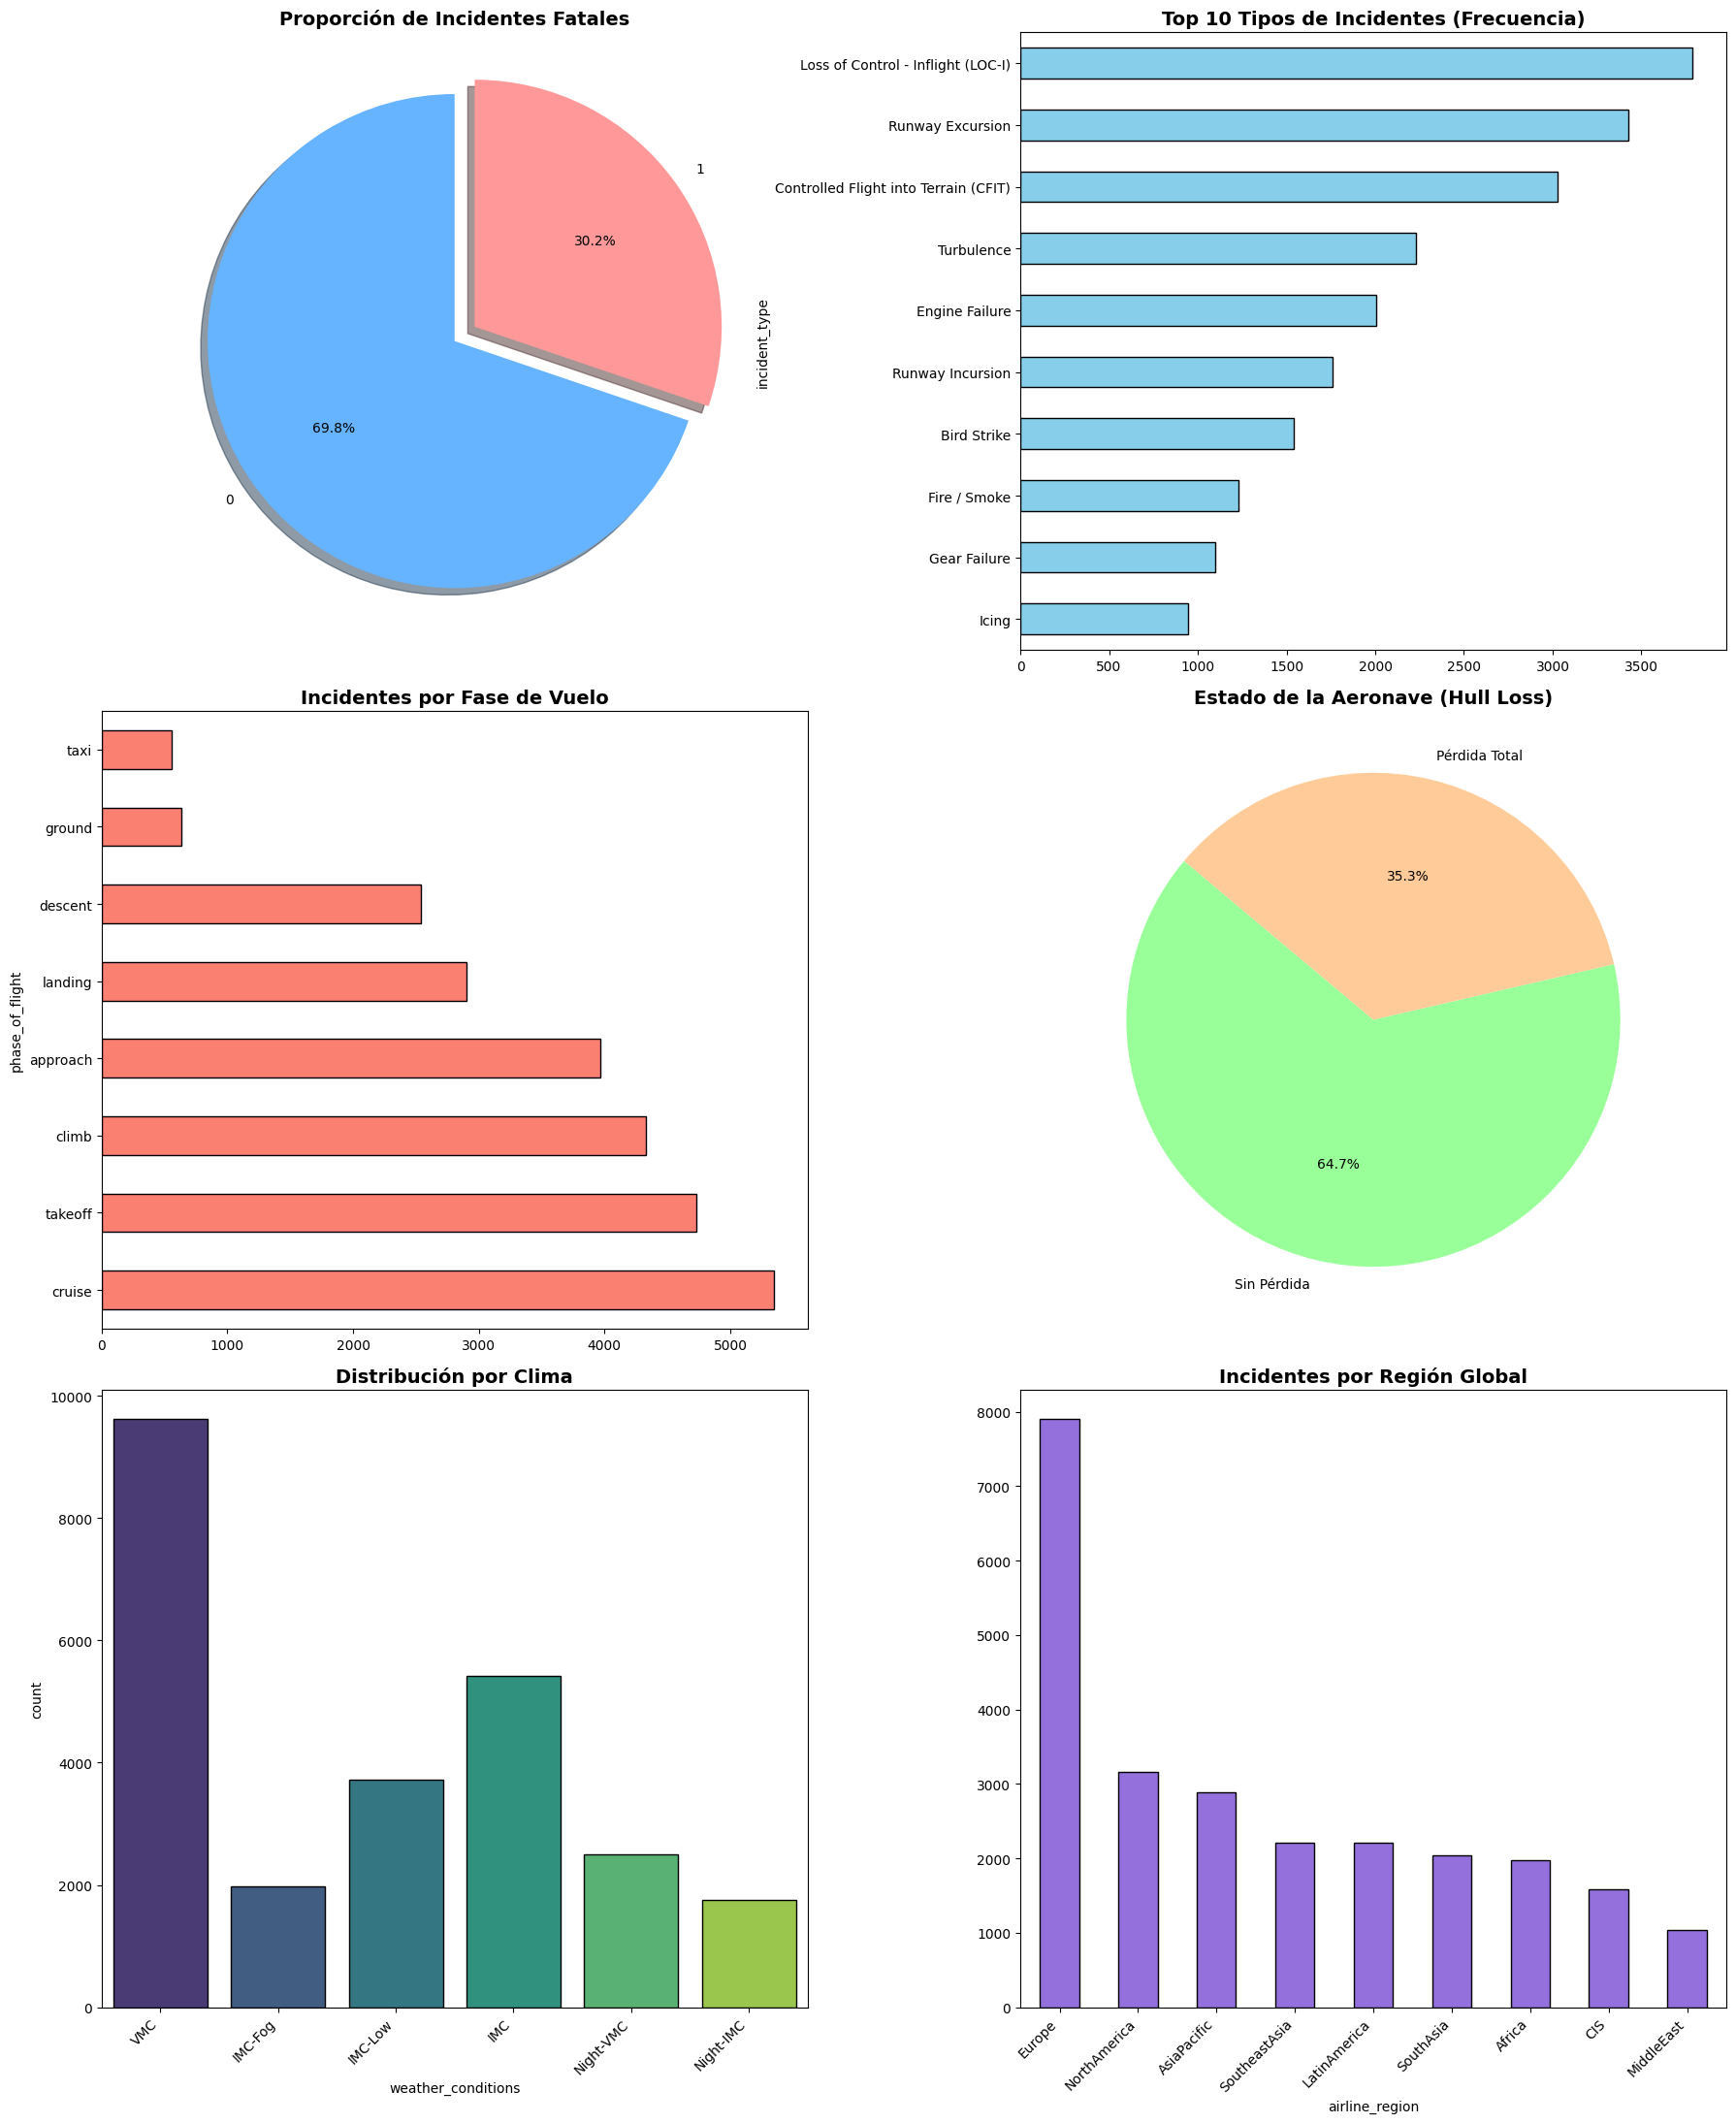

In [11]:
# 1. Lista de columnas categóricas a graficar.
categorical_cols = [
    ('is_fatal', 'Gravedad: ¿Hubo fallecidos?', 'Fatalidad (1=Sí, 0=No)', 'darkred'),
    ('incident_type', 'Tipo de Incidente', 'Categoría de Suceso', 'steelblue'),
    ('phase_of_flight', 'Fase del Vuelo', 'Momento del Incidente', 'darkorange'),
    ('weather_conditions', 'Condiciones Climáticas', 'Estado del Clima', 'gray'),
    ('hull_loss', 'Pérdida Total del Avión', 'Hull Loss (1=Sí, 0=No)', 'black'),
    ('airline_region', 'Región de la Aerolínea', 'Región Global', 'seagreen')
]

# Configuración de la figura con distribucion 3x2
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
axes = axes.flatten()

# 1
df_incidents['is_fatal'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'],
    explode=[0, 0.1], shadow=True, startangle=90
)
axes[0].set_title('Proporción de Incidentes Fatales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

#2
df_incidents['incident_type'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='skyblue', edgecolor='black'
)
axes[1].set_title('Top 10 Tipos de Incidentes (Frecuencia)', fontsize=14, fontweight='bold')

# 3
df_incidents['phase_of_flight'].value_counts().plot(
    kind='barh', ax=axes[2], color='salmon', edgecolor='black'
)
axes[2].set_title('Incidentes por Fase de Vuelo', fontsize=14, fontweight='bold')

# 4
df_incidents['hull_loss'].value_counts().plot(
    kind='pie', ax=axes[3], autopct='%1.1f%%', colors=['#99ff99','#ffcc99'],
    labels=['Sin Pérdida', 'Pérdida Total'], startangle=140
)
axes[3].set_title('Estado de la Aeronave (Hull Loss)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('')

# 5
sns.countplot(data=df_incidents, x='weather_conditions', ax=axes[4], palette='viridis', edgecolor='black')
axes[4].set_title('Distribución por Clima', fontsize=14, fontweight='bold')
plt.setp(axes[4].get_xticklabels(), rotation=45, ha='right')

# 6
df_incidents['airline_region'].value_counts().plot(
    kind='bar', ax=axes[5], color='mediumpurple', edgecolor='black'
)
axes[5].set_title('Incidentes por Región Global', fontsize=14, fontweight='bold')
plt.setp(axes[5].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

A través de esta visualización, podemos analizar la distribución de las variables categóricas en un formato de frecuencias. Es notable que variables clave de severidad como is_fatal y hull_loss ya vienen estandarizadas en formato binario 0 y 1, a diferencia de otros datasets que usan 1 y 2. Esto es una ventaja para el entrenamiento de modelos de clasificación, aunque se observa un fuerte desbalance de clases (más casos no fatales), factor que deberemos tratar en la fase de preparación para evitar sesgos en la predicción.

In [12]:
df_incidents['airline_country'].unique()

array(['Kenya', 'Portugal', 'USA', 'Togo', 'France', 'Poland', 'Mexico',
       'Indonesia', 'Hungary', 'Kazakhstan', 'Algeria', 'Croatia',
       'Chile', 'Japan', 'Australia', 'Canada', 'Pakistan', 'Belgium',
       'Romania', 'Russia', 'India', 'NorthKorea', 'UAE', 'Azerbaijan',
       'Angola', 'Philippines', 'Vietnam', 'UK', 'Colombia', 'Germany',
       'Singapore', 'Spain', 'SouthKorea', 'Greece', 'Morocco', 'China',
       'Nepal', 'Brazil', 'Egypt', 'Netherlands', 'Ireland',
       'SouthAfrica', 'Malaysia', 'Mongolia', 'Switzerland', 'SriLanka',
       'Italy', 'Cameroon', 'Turkey', 'Qatar', 'Ethiopia', 'Venezuela',
       'Ecuador', 'Peru', 'Bangladesh', 'Finland', 'HongKong', 'Cuba',
       'Thailand', 'Sweden', 'Slovenia'], dtype=object)

In [13]:
df_incidents['airline'].unique()

array(['Kenya Airways', 'TAP Air Portugal', 'American Airlines',
       'ASKY Airlines', 'Air France', 'LOT Polish Airlines',
       'Mexicana de Aviación', 'Garuda Indonesia', 'Wizz Air',
       'Air Astana', 'Air Algérie', 'Croatia Airlines', 'LATAM Airlines',
       'Japan Airlines', 'Qantas', 'Sunwing Airlines',
       'Pakistan International', 'Sabena', 'Tarom', 'S7 Airlines',
       'SpiceJet', 'Air Koryo', 'Air Arabia', 'Azal',
       'TAAG Angola Airlines', 'IndiGo', 'Cebu Pacific',
       'Vietnam Airlines', 'Etihad Airways', 'Delta Air Lines', 'easyJet',
       'Flybe', 'Aeromexico', 'Avianca', 'ANA', 'Condor',
       'Southwest Airlines', 'Singapore Airlines', 'Aviaco',
       'United Airlines', 'Monarch Airlines', 'Korean Air',
       'Olympic Airways', 'Royal Air Maroc', 'Philippine Airlines',
       'Ural Airlines', 'China Southern', 'WestJet', 'Aeroflot',
       'China Eastern', 'Nepal Airlines', 'GOL Airlines', 'TWA', 'Malév',
       'EgyptAir', 'KLM', 'Ryanair', 'Trans

In [14]:
df_incidents.describe().round(2)

,year,month,aircraft_age_years,manufacture_year,is_fatal,fatalities,occupants_onboard,injuries,hull_loss,engines,seats_config
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,1990.21,6.49,11.56,1990.35,0.30,12.95,114.38,9.31,0.35,2.36,151.28
std,14.30,3.45,5.86,14.32,0.46,37.18,90.36,13.90,0.48,0.76,114.22
min,1970.00,1.00,0.00,1946.00,0.00,0.00,1.00,0.00,0.00,1.00,9.00
25%,1978.00,3.00,7.00,1980.00,0.00,0.00,47.00,0.00,0.00,2.00,70.00
50%,1988.00,6.00,11.00,1990.00,0.00,0.00,97.00,3.00,0.00,2.00,130.00
75%,2000.00,9.00,16.00,2000.00,1.00,4.00,155.00,14.00,1.00,2.00,181.00
max,2024.00,12.00,39.00,2024.00,1.00,526.00,555.00,112.00,1.00,4.00,555.00


En este estudio, la presencia de valores nulos en variables numericas criticas puede sesgar las estidisticas descriptivas. En este proyecto, la prioridad sera garantizar la integridad de las cifras de opucantes y daños.

Utilizaremos tecnicas de imputación basadas en la moda para variables categoricas de baja ausencia, lo que nos asegura que nos sirvan como predictores fiables para las variables cuantitativas mas complejas.

In [15]:
# Creamos df2 como copia para mantener la integridad del original
df2 = df_incidents.copy()
print("Copia df2 creada. Listos para iniciar el tratamiento de nulos.")

# Definimos columnas para imputar por la Moda (Variables de baja ausencia)
# Incluimos damage_category que es la que tiene nulos en tu info()
cols_categoricas = ['damage_category', 'aircraft_category', 'incident_type']

for col in cols_categoricas:
    if col in df2.columns:
        df2[col] = df2[col].fillna(df2[col].mode()[0])

print("Fase 1 completada: Variables categóricas y de daño imputadas por moda.")

# 3. Verificación de nulos post-limpieza
print("\nValores nulos actuales:")
print(df2[cols_categoricas].isnull().sum())

Copia df2 creada. Listos para iniciar el tratamiento de nulos.
Fase 1 completada: Variables categóricas y de daño imputadas por moda.

Valores nulos actuales:
damage_category      0
aircraft_category    0
incident_type        0
dtype: int64


Se generó una copia df2 para el tratamiento de datos sin alterar la fuente. Se aplicó imputación por moda en variables categóricas como damage_category, asegurando la integridad de las etiquetas de gravedad antes de procesar las variables numéricas. Esto previene sesgos en la clasificación de daños y prepara el dataset para el análisis de correlación.

In [16]:
# Filtro de inconsistencia lógica: Víctimas > Ocupantes
incoherentes = df2[(df2['fatalities'] + df2['injuries']) > df2['occupants_onboard']]

print(f"Se encontraron {len(incoherentes)} casos con más víctimas que ocupantes.")

# Filtro de capacidad: Ocupantes que exceden por mucho la configuración de asientos
# (Margen de error del 10% por tripulación o infantes sin asiento)
sobrepoblados = df2[df2['occupants_onboard'] > (df2['seats_config'] * 1.1)]

print(f"Se detectaron {len(sobrepoblados)} registros con exceso de capacidad sospechoso.")

# Limpieza de df2
total_eliminados = len(incoherentes) + len(sobrepoblados)
indices_a_borrar = pd.concat([incoherentes, sobrepoblados]).index.unique()
df2 = df2.drop(indices_a_borrar)

print(f"Limpieza ejecutada. Se eliminaron {len(indices_a_borrar)} registros inconsistentes.")
print("Filas restantes en el dataset: ", df2.shape)

Se encontraron 0 casos con más víctimas que ocupantes.
Se detectaron 0 registros con exceso de capacidad sospechoso.
Limpieza ejecutada. Se eliminaron 0 registros inconsistentes.
Filas restantes en el dataset:  (25000, 29)


Con este filtro de integridad se busca eliminar registros con contradicciones numericas, como incidentes donde el numero de victimas superaba al de opucantes. Esta remocion de valores nos permite asegurar que el modelo no se entrene con fallas estadisticas manteniendo una relacion logica.

# Estadisticos basicos y distribucion de valores.

In [17]:

df2.describe().round(2)

,year,month,aircraft_age_years,manufacture_year,is_fatal,fatalities,occupants_onboard,injuries,hull_loss,engines,seats_config
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,1990.21,6.49,11.56,1990.35,0.30,12.95,114.38,9.31,0.35,2.36,151.28
std,14.30,3.45,5.86,14.32,0.46,37.18,90.36,13.90,0.48,0.76,114.22
min,1970.00,1.00,0.00,1946.00,0.00,0.00,1.00,0.00,0.00,1.00,9.00
25%,1978.00,3.00,7.00,1980.00,0.00,0.00,47.00,0.00,0.00,2.00,70.00
50%,1988.00,6.00,11.00,1990.00,0.00,0.00,97.00,3.00,0.00,2.00,130.00
75%,2000.00,9.00,16.00,2000.00,1.00,4.00,155.00,14.00,1.00,2.00,181.00
max,2024.00,12.00,39.00,2024.00,1.00,526.00,555.00,112.00,1.00,4.00,555.00


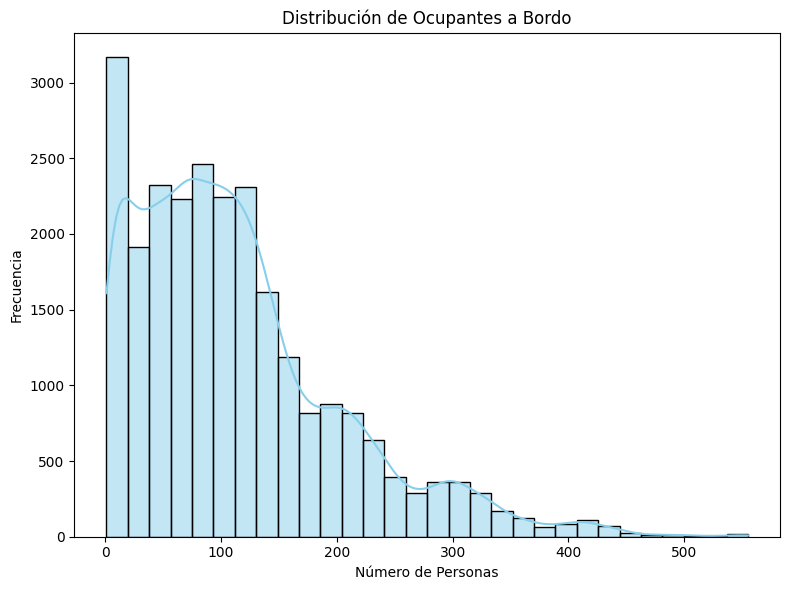

In [18]:
# Histograma para los Ocupantes a Bordo
plt.figure(figsize=(8, 6))
sns.histplot(df2['occupants_onboard'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Ocupantes a Bordo')
plt.xlabel('Número de Personas')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La distribución es multimodal, reflejando distintos tipos de operación: vuelos regionales y comerciales de gran capacidad. La mayoría de los incidentes ocurren en aeronaves con menos de 150 personas.

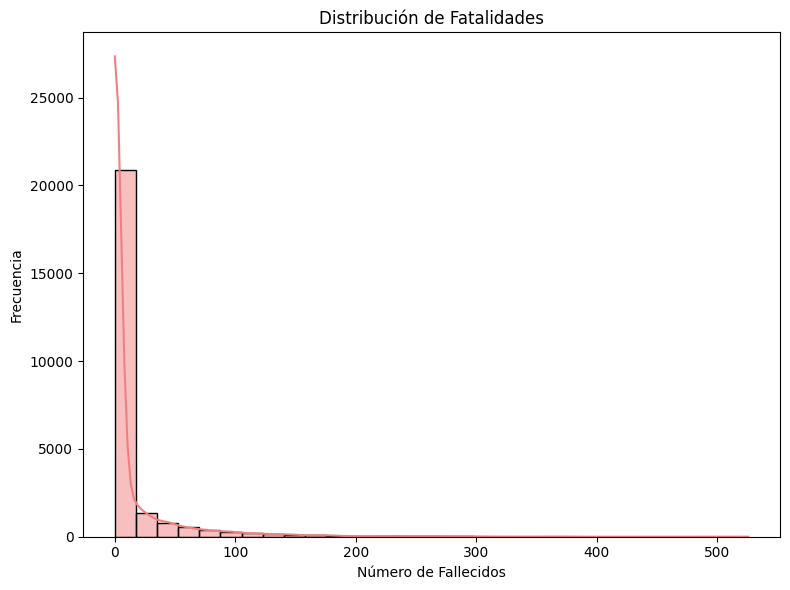

In [19]:
# Histograma para las Fatalidades
plt.figure(figsize=(8, 6))
sns.histplot(df2['fatalities'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución de Fatalidades')
plt.xlabel('Número de Fallecidos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Presenta un sesgo extremo hacia la izquierda (cero), indicando que la gran mayoría de los eventos son incidentes de seguridad sin víctimas mortales, lo que confirma la alta tasa de supervivencia en la aviación moderna.

# Fase 3: Preparación de Datos y Codificación (Encoding)


Se aplican diversos métodos de codificación para transformar variables categóricas en formatos numéricos procesables. Se utiliza One-Hot Encoding para variables con pocas categorías, Ordinal Encoding para la severidad del daño (respetando su jerarquía) y Binary Encoding para el fabricante, optimizando así el espacio en memoria y evitando el sobreajuste del modelo.

In [20]:
# Eliminación de columnas irrelevantes
df_incidents = df2.drop(columns=[
    'incident_id','date','region' ,'airline_country', 'aircraft_type', 'manufacture_year',
    'departure_airport', 'arrival_airport', 'country', 'month', 'airline'
])

In [21]:
# Ordinal Encoding para damage_category
# Definimos el orden: cuanto más alto el número, más grave es el daño
damage_map = {'Minor': 1, 'Substantial': 2, 'Serious': 3, 'Destroyed': 4}
df_incidents['damage_category'] = df_incidents['damage_category'].map(damage_map)

In [22]:
# Binary Encoding para Manufacturer que contiene 31 categorias, alta cardinalidad
encoder_bin = ce.BinaryEncoder(cols=['manufacturer'])
df_incidents = encoder_bin.fit_transform(df_incidents)

In [23]:
# 5. One-Hot Encoding para las variables de texto restantes
cols_onehot = [
    'airline_region', 'aircraft_category', 'phase_of_flight',
    'weather_conditions', 'investigation_status', 'incident_type', 'primary_cause'
]
df_incidents = pd.get_dummies(df_incidents, columns=cols_onehot, drop_first=True)

In [24]:
# 6. Verificación Final de tipos de datos
print("Columnas de tipo texto restantes:", df_incidents.select_dtypes(include=['object']).columns.tolist())
print(f"Dimensiones finales definitivas: {df_incidents.shape}")

Columnas de tipo texto restantes: []
Dimensiones finales definitivas: (25000, 80)


In [25]:
print(df_incidents.columns)

Index(['year', 'manufacturer_0', 'manufacturer_1', 'manufacturer_2',
       'manufacturer_3', 'manufacturer_4', 'aircraft_age_years', 'is_fatal',
       'fatalities', 'occupants_onboard', 'injuries', 'hull_loss',
       'damage_category', 'engines', 'seats_config',
       'airline_region_AsiaPacific', 'airline_region_CIS',
       'airline_region_Europe', 'airline_region_LatinAmerica',
       'airline_region_MiddleEast', 'airline_region_NorthAmerica',
       'airline_region_SouthAsia', 'airline_region_SoutheastAsia',
       'aircraft_category_Piston', 'aircraft_category_Regional',
       'aircraft_category_Superjumbo', 'aircraft_category_Supersonic',
       'aircraft_category_Turboprop', 'aircraft_category_Widebody',
       'phase_of_flight_climb', 'phase_of_flight_cruise',
       'phase_of_flight_descent', 'phase_of_flight_ground',
       'phase_of_flight_landing', 'phase_of_flight_takeoff',
       'phase_of_flight_taxi', 'weather_conditions_IMC-Fog',
       'weather_conditions_IMC-Low

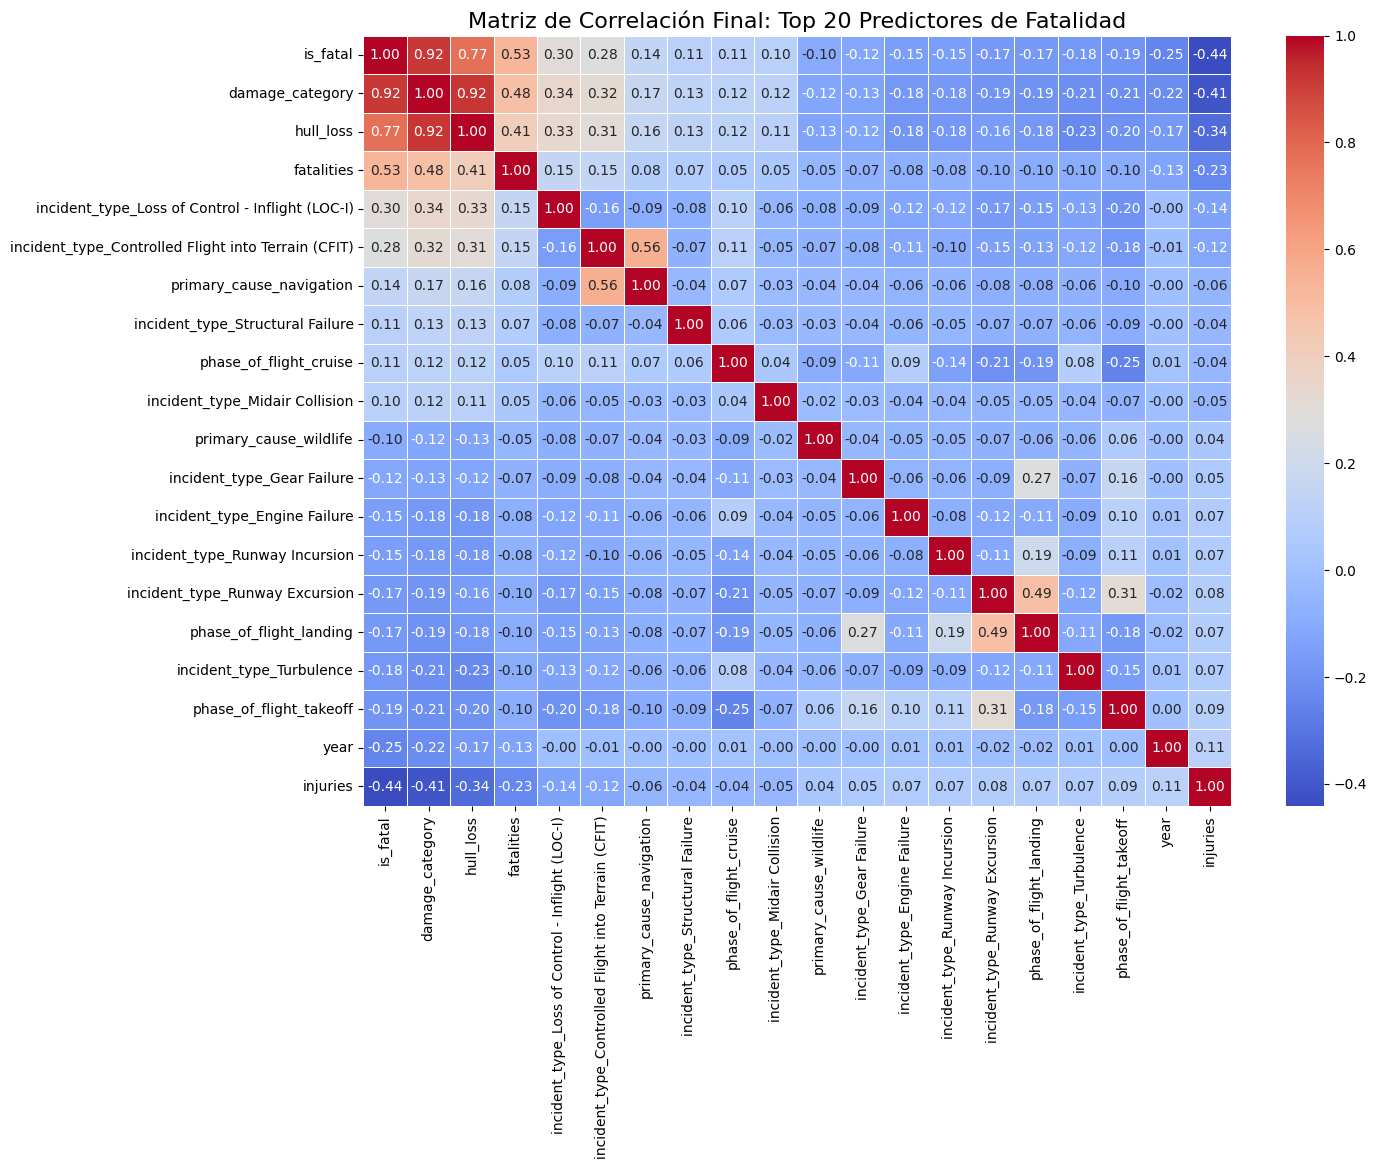

In [26]:
correlaciones = df_incidents.corr()['is_fatal'].sort_values(ascending=False)

# seleccionamos los 10 factores con mayor correlación positiva y los 10 con mayor negativa
top_features = pd.concat([correlaciones.head(10), correlaciones.tail(10)])

# graficamos el Mapa de Calor
plt.figure(figsize=(14, 10))
sns.heatmap(df_incidents[top_features.index].corr(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Matriz de Correlación Final: Top 20 Predictores de Fatalidad', fontsize=16)
plt.show()

El mapa de calor nos refleja que la destruccion del avion (hull_loss) y la gravedad del daño son las señales mas fuertes para predecir si un accidente será fatal. Sus colores nos indica que las variables no se repiten entre si, lo que confirma que nuestros datos quedaron limpios para entrenar al modelo predictivo.